In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/banking_customer_transaction_behaviour_500.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display the shape of the DataFrame
print("\nShape of the dataset (rows, columns):")
print(df.shape)

# Display information about the DataFrame (column names, non-null counts, data types)
print("\nInformation about the dataset:")
df.info()

First 5 rows of the dataset:


,Customer_ID,Age_Group,Occupation,City,UPI_Count,Card_Count,ATM_Count,Deposits,Withdrawals,Bill_Payments
0,C0001,26-35,Private Employee,Chennai,48,38,2,58437,14275,11
1,C0002,56-65,Government,Salem,12,6,22,14996,18095,4
2,C0003,46-55,IT Professional,Madurai,31,16,7,45070,9966,5
3,C0004,36-45,Self-Employed,Tiruchirappalli,27,5,7,81010,9466,12
4,C0005,18-25,Private Employee,Tiruchirappalli,48,21,5,38830,10400,10



Shape of the dataset (rows, columns):
(500, 10)

Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer_ID    500 non-null    object
 1   Age_Group      500 non-null    object
 2   Occupation     500 non-null    object
 3   City           500 non-null    object
 4   UPI_Count      500 non-null    int64 
 5   Card_Count     500 non-null    int64 
 6   ATM_Count      500 non-null    int64 
 7   Deposits       500 non-null    int64 
 8   Withdrawals    500 non-null    int64 
 9   Bill_Payments  500 non-null    int64 
dtypes: int64(6), object(4)
memory usage: 39.2+ KB


In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("\nRemoving duplicate rows...")
    df.drop_duplicates(inplace=True)
    print(f"Number of rows after removing duplicates: {df.shape[0]}")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Display columns with missing values and their percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': missing_percentage
})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if not missing_df.empty:
    print("\nColumns with missing values:")
    print(missing_df)
else:
    print("\nNo missing values found in the dataset.")

Missing values per column:
Customer_ID      0
Age_Group        0
Occupation       0
City             0
UPI_Count        0
Card_Count       0
ATM_Count        0
Deposits         0
Withdrawals      0
Bill_Payments    0
dtype: int64

No missing values found in the dataset.


In [ ]:
# Check unique values in categorical columns
print("\nUnique values in 'Age_Group':")
print(df['Age_Group'].unique())

print("\nUnique values in 'Occupation':")
print(df['Occupation'].unique())

print("\nUnique values in 'City':")
print(df['City'].unique())


Unique values in 'Age_Group':
['26-35' '56-65' '46-55' '36-45' '18-25' '65+']

Unique values in 'Occupation':
['Private Employee' 'Government' 'IT Professional' 'Self-Employed'
 'Student' 'Retired' 'Business']

Unique values in 'City':
['Chennai' 'Salem' 'Madurai' 'Tiruchirappalli' 'Erode' 'Bengaluru'
 'Tiruppur' 'Coimbatore']


In [ ]:
# Perform descriptive statistics for numerical variables
print("\nDescriptive Statistics for Numerical Variables:")
display(df.describe())


Descriptive Statistics for Numerical Variables:


,UPI_Count,Card_Count,ATM_Count,Deposits,Withdrawals,Bill_Payments
count,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,38.046000,19.962000,6.71600,59442.006000,15070.834000,10.522000
std,19.822051,9.884734,6.83995,39131.559638,12468.236811,5.302617
min,5.000000,1.000000,0.00000,6609.000000,1407.000000,0.000000
25%,26.000000,13.000000,2.00000,33422.500000,7209.000000,7.000000
50%,36.000000,19.000000,5.00000,50746.000000,11370.500000,10.000000
75%,47.000000,25.000000,9.00000,74370.500000,19082.250000,13.000000
max,225.000000,69.000000,72.00000,296378.000000,114715.000000,36.000000


In [ ]:
# Perform descriptive statistics for categorical variables
print("\nDescriptive Statistics for Categorical Variables:")
print("\nValue Counts for 'Age_Group':")
print(df['Age_Group'].value_counts())

print("\nValue Counts for 'Occupation':")
print(df['Occupation'].value_counts())

print("\nValue Counts for 'City':")
print(df['City'].value_counts())


Descriptive Statistics for Categorical Variables:

Value Counts for 'Age_Group':
Age_Group
26-35    125
36-45    116
18-25    116
46-55     70
56-65     49
65+       24
Name: count, dtype: int64

Value Counts for 'Occupation':
Occupation
IT Professional     101
Student             101
Private Employee     77
Self-Employed        71
Business             69
Government           59
Retired              22
Name: count, dtype: int64

Value Counts for 'City':
City
Chennai            100
Coimbatore          79
Bengaluru           72
Erode               56
Madurai             52
Tiruppur            49
Salem               47
Tiruchirappalli     45
Name: count, dtype: int64


In [ ]:
# Feature Engineering

# Digital_Transactions = UPI_Count + Card_Count + Bill_Payments
df['Digital_Transactions'] = df['UPI_Count'] + df['Card_Count'] + df['Bill_Payments']

# Total_Transactions = UPI_Count + Card_Count + ATM_Count + Bill_Payments
df['Total_Transactions'] = df['UPI_Count'] + df['Card_Count'] + df['ATM_Count'] + df['Bill_Payments']

# Digital_Ratio = Digital_Transactions / Total_Transactions
df['Digital_Ratio'] = df['Digital_Transactions'] / df['Total_Transactions']

# ATM_Ratio = ATM_Count / Total_Transactions
df['ATM_Ratio'] = df['ATM_Count'] / df['Total_Transactions']

# Display the first few rows with the new features
print("DataFrame with new engineered features:")
display(df.head())

DataFrame with new engineered features:


,Customer_ID,Age_Group,Occupation,City,UPI_Count,Card_Count,ATM_Count,Deposits,Withdrawals,Bill_Payments,Digital_Transactions,Total_Transactions,Digital_Ratio,ATM_Ratio
0,C0001,26-35,Private Employee,Chennai,48,38,2,58437,14275,11,97,99,0.979798,0.020202
1,C0002,56-65,Government,Salem,12,6,22,14996,18095,4,22,44,0.500000,0.500000
2,C0003,46-55,IT Professional,Madurai,31,16,7,45070,9966,5,52,59,0.881356,0.118644
3,C0004,36-45,Self-Employed,Tiruchirappalli,27,5,7,81010,9466,12,44,51,0.862745,0.137255
4,C0005,18-25,Private Employee,Tiruchirappalli,48,21,5,38830,10400,10,79,84,0.940476,0.059524


In [ ]:
# Create 'Digital_User' target variable
# We will classify a customer as a 'Digital_User' if their 'Digital_Ratio' is greater than or equal to 0.7 (70%).
# This threshold signifies that 70% or more of their total transactions are digital.

df['Digital_User'] = (df['Digital_Ratio'] >= 0.7).astype(int)

print("Distribution of 'Digital_User' target variable:")
print(df['Digital_User'].value_counts())

print("\nFirst 5 rows with the new 'Digital_User' target:")
display(df[['Digital_Ratio', 'Digital_User']].head())

Distribution of 'Digital_User' target variable:
Digital_User
1    446
0     54
Name: count, dtype: int64

First 5 rows with the new 'Digital_User' target:


,Digital_Ratio,Digital_User
0,0.979798,1
1,0.500000,0
2,0.881356,1
3,0.862745,1
4,0.940476,1


In [ ]:
# EDA: Transaction behaviour by Age_Group
print("\nTransaction behaviour by Age_Group:")
age_group_transactions = df.groupby('Age_Group')[['UPI_Count', 'Card_Count', 'ATM_Count', 'Bill_Payments', 'Digital_Transactions', 'Total_Transactions']].mean().sort_values(by='Total_Transactions', ascending=False)
display(age_group_transactions)

# Also look at Digital_Ratio and ATM_Ratio by Age_Group
print("\nDigital and ATM Ratio by Age_Group:")
age_group_ratios = df.groupby('Age_Group')[['Digital_Ratio', 'ATM_Ratio']].mean().sort_values(by='Digital_Ratio', ascending=False)
display(age_group_ratios)


Transaction behaviour by Age_Group:


,UPI_Count,Card_Count,ATM_Count,Bill_Payments,Digital_Transactions,Total_Transactions
Age_Group,,,,,,
18-25,48.112069,26.129310,2.155172,14.137931,88.379310,90.534483
26-35,44.040000,23.056000,3.360000,11.848000,78.944000,82.304000
36-45,38.413793,19.362069,6.275862,10.422414,68.198276,74.474138
46-55,29.328571,16.014286,9.085714,7.714286,53.057143,62.142857
56-65,22.367347,10.857143,16.795918,5.795918,39.020408,55.816327
65+,13.833333,7.041667,20.875000,4.458333,25.333333,46.208333



Digital and ATM Ratio by Age_Group:


,Digital_Ratio,ATM_Ratio
Age_Group,,
18-25,0.972504,0.027496
26-35,0.955162,0.044838
36-45,0.910329,0.089671
46-55,0.842252,0.157748
56-65,0.695807,0.304193
65+,0.546108,0.453892


In [ ]:
# EDA: Transaction behaviour by Occupation
print("\nTransaction behaviour by Occupation:")
occupation_transactions = df.groupby('Occupation')[['UPI_Count', 'Card_Count', 'ATM_Count', 'Bill_Payments', 'Digital_Transactions', 'Total_Transactions']].mean().sort_values(by='Total_Transactions', ascending=False)
display(occupation_transactions)

# Also look at Digital_Ratio and ATM_Ratio by Occupation
print("\nDigital and ATM Ratio by Occupation:")
occupation_ratios = df.groupby('Occupation')[['Digital_Ratio', 'ATM_Ratio']].mean().sort_values(by='Digital_Ratio', ascending=False)
display(occupation_ratios)


Transaction behaviour by Occupation:


,UPI_Count,Card_Count,ATM_Count,Bill_Payments,Digital_Transactions,Total_Transactions
Occupation,,,,,,
IT Professional,47.049505,25.356436,5.504950,13.326733,85.732673,91.237624
Student,42.702970,22.376238,5.792079,11.653465,76.732673,82.524752
Private Employee,37.623377,19.831169,6.467532,10.116883,67.571429,74.038961
Business,35.913043,18.449275,7.695652,10.376812,64.739130,72.434783
Government,32.050847,15.305085,9.169492,8.423729,55.779661,64.949153
Self-Employed,31.619718,17.408451,6.830986,8.535211,57.563380,64.394366
Retired,20.318182,10.045455,7.363636,6.363636,36.727273,44.090909



Digital and ATM Ratio by Occupation:


,Digital_Ratio,ATM_Ratio
Occupation,,
IT Professional,0.923202,0.076798
Student,0.908005,0.091995
Private Employee,0.893998,0.106002
Self-Employed,0.877214,0.122786
Business,0.872000,0.128000
Government,0.842024,0.157976
Retired,0.820155,0.179845


In [ ]:
# EDA: Transaction behaviour by City
print("\nTransaction behaviour by City:")
city_transactions = df.groupby('City')[['UPI_Count', 'Card_Count', 'ATM_Count', 'Bill_Payments', 'Digital_Transactions', 'Total_Transactions']].mean().sort_values(by='Total_Transactions', ascending=False)
display(city_transactions)

# Also look at Digital_Ratio and ATM_Ratio by City
print("\nDigital and ATM Ratio by City:")
city_ratios = df.groupby('City')[['Digital_Ratio', 'ATM_Ratio']].mean().sort_values(by='Digital_Ratio', ascending=False)
display(city_ratios)


Transaction behaviour by City:


,UPI_Count,Card_Count,ATM_Count,Bill_Payments,Digital_Transactions,Total_Transactions
City,,,,,,
Bengaluru,49.736111,26.569444,4.833333,13.513889,89.819444,94.652778
Chennai,43.400000,22.600000,5.690000,11.440000,77.440000,83.130000
Coimbatore,36.443038,20.164557,5.708861,11.164557,67.772152,73.481013
Tiruppur,35.102041,18.163265,7.959184,10.224490,63.489796,71.448980
Tiruchirappalli,35.600000,16.600000,9.022222,8.733333,60.933333,69.955556
Madurai,33.480769,16.615385,6.576923,8.576923,58.673077,65.250000
Erode,31.500000,17.357143,6.821429,9.142857,58.000000,64.821429
Salem,29.702128,15.787234,10.000000,8.723404,54.212766,64.212766



Digital and ATM Ratio by City:


,Digital_Ratio,ATM_Ratio
City,,
Bengaluru,0.936502,0.063498
Chennai,0.910807,0.089193
Coimbatore,0.902997,0.097003
Erode,0.877821,0.122179
Madurai,0.877569,0.122431
Tiruppur,0.859993,0.140007
Tiruchirappalli,0.850159,0.149841
Salem,0.828274,0.171726


In [ ]:
# EDA: Analysis of Individual Transaction Channels
print("\nDescriptive statistics for individual transaction channels:")
display(df[['UPI_Count', 'Card_Count', 'ATM_Count', 'Bill_Payments']].describe())

print("\nTotal counts for individual transaction channels:")
print(f"Total UPI Transactions: {df['UPI_Count'].sum()}")
print(f"Total Card Transactions: {df['Card_Count'].sum()}")
print(f"Total ATM Transactions: {df['ATM_Count'].sum()}")
print(f"Total Bill Payments: {df['Bill_Payments'].sum()}")

# Also look at the distribution of Digital_Transactions and Total_Transactions
print("\nDescriptive statistics for Digital and Total Transactions:")
display(df[['Digital_Transactions', 'Total_Transactions']].describe())


Descriptive statistics for individual transaction channels:


,UPI_Count,Card_Count,ATM_Count,Bill_Payments
count,500.000000,500.000000,500.00000,500.000000
mean,38.046000,19.962000,6.71600,10.522000
std,19.822051,9.884734,6.83995,5.302617
min,5.000000,1.000000,0.00000,0.000000
25%,26.000000,13.000000,2.00000,7.000000
50%,36.000000,19.000000,5.00000,10.000000
75%,47.000000,25.000000,9.00000,13.000000
max,225.000000,69.000000,72.00000,36.000000



Total counts for individual transaction channels:
Total UPI Transactions: 19023
Total Card Transactions: 9981
Total ATM Transactions: 3358
Total Bill Payments: 5261

Descriptive statistics for Digital and Total Transactions:


,Digital_Transactions,Total_Transactions
count,500.0000,500.000000
mean,68.5300,75.246000
std,32.4921,30.971082
min,14.0000,27.000000
25%,47.7500,56.000000
50%,64.0000,69.000000
75%,84.0000,87.000000
max,330.0000,348.000000


In [ ]:
# EDA: Analysis of Deposits and Withdrawals
print("\nDescriptive statistics for Deposits and Withdrawals:")
display(df[['Deposits', 'Withdrawals']].describe())

print("\nTotal Deposits and Withdrawals:")
print(f"Total Deposits: {df['Deposits'].sum()}")
print(f"Total Withdrawals: {df['Withdrawals'].sum()}")


Descriptive statistics for Deposits and Withdrawals:


,Deposits,Withdrawals
count,500.000000,500.000000
mean,59442.006000,15070.834000
std,39131.559638,12468.236811
min,6609.000000,1407.000000
25%,33422.500000,7209.000000
50%,50746.000000,11370.500000
75%,74370.500000,19082.250000
max,296378.000000,114715.000000



Total Deposits and Withdrawals:
Total Deposits: 29721003
Total Withdrawals: 7535417


In [ ]:
# EDA: Analysis of Digital Adoption (overall and by segments)
print("\nOverall Digital User Distribution:")
display(df['Digital_User'].value_counts().rename(index={1: 'Digital User', 0: 'Non-Digital User'}))

print("\nOverall Average Digital Ratio:")
print(f"Average Digital Ratio across all customers: {df['Digital_Ratio'].mean():.2f}")

print("\nAverage Digital Ratio by Age Group (revisiting):")
display(age_group_ratios['Digital_Ratio'])

print("\nAverage Digital Ratio by Occupation (revisiting):")
display(occupation_ratios['Digital_Ratio'])

print("\nAverage Digital Ratio by City (revisiting):")
display(city_ratios['Digital_Ratio'])


Overall Digital User Distribution:


,count
Digital_User,
Digital User,446
Non-Digital User,54



Overall Average Digital Ratio:
Average Digital Ratio across all customers: 0.89

Average Digital Ratio by Age Group (revisiting):


,Digital_Ratio
Age_Group,
18-25,0.972504
26-35,0.955162
36-45,0.910329
46-55,0.842252
56-65,0.695807
65+,0.546108



Average Digital Ratio by Occupation (revisiting):


,Digital_Ratio
Occupation,
IT Professional,0.923202
Student,0.908005
Private Employee,0.893998
Self-Employed,0.877214
Business,0.872000
Government,0.842024
Retired,0.820155



Average Digital Ratio by City (revisiting):


,Digital_Ratio
City,
Bengaluru,0.936502
Chennai,0.910807
Coimbatore,0.902997
Erode,0.877821
Madurai,0.877569
Tiruppur,0.859993
Tiruchirappalli,0.850159
Salem,0.828274


In [ ]:
# Display the truncated outputs for Digital Ratio by Occupation and City
print("\nAverage Digital Ratio by Occupation (complete view):")
display(occupation_ratios['Digital_Ratio'])

print("\nAverage Digital Ratio by City (complete view):")
display(city_ratios['Digital_Ratio'])


Average Digital Ratio by Occupation (complete view):


,Digital_Ratio
Occupation,
IT Professional,0.923202
Student,0.908005
Private Employee,0.893998
Self-Employed,0.877214
Business,0.872000
Government,0.842024
Retired,0.820155



Average Digital Ratio by City (complete view):


,Digital_Ratio
City,
Bengaluru,0.936502
Chennai,0.910807
Coimbatore,0.902997
Erode,0.877821
Madurai,0.877569
Tiruppur,0.859993
Tiruchirappalli,0.850159
Salem,0.828274


In [ ]:
# EDA: Analysis of ATM dependence (overall and by segments)
print("\nOverall Average ATM Ratio:")
print(f"Average ATM Ratio across all customers: {df['ATM_Ratio'].mean():.2f}")

print("\nAverage ATM Ratio by Age Group (revisiting):")
display(age_group_ratios['ATM_Ratio'])

print("\nAverage ATM Ratio by Occupation (revisiting):")
display(occupation_ratios['ATM_Ratio'])

print("\nAverage ATM Ratio by City (revisiting):")
display(city_ratios['ATM_Ratio'])


Overall Average ATM Ratio:
Average ATM Ratio across all customers: 0.11

Average ATM Ratio by Age Group (revisiting):


,ATM_Ratio
Age_Group,
18-25,0.027496
26-35,0.044838
36-45,0.089671
46-55,0.157748
56-65,0.304193
65+,0.453892



Average ATM Ratio by Occupation (revisiting):


,ATM_Ratio
Occupation,
IT Professional,0.076798
Student,0.091995
Private Employee,0.106002
Self-Employed,0.122786
Business,0.128000
Government,0.157976
Retired,0.179845



Average ATM Ratio by City (revisiting):


,ATM_Ratio
City,
Bengaluru,0.063498
Chennai,0.089193
Coimbatore,0.097003
Erode,0.122179
Madurai,0.122431
Tiruppur,0.140007
Tiruchirappalli,0.149841
Salem,0.171726


In [ ]:
# Display the truncated output for ATM Ratio by City (complete view)
print("\nAverage ATM Ratio by City (complete view):")
display(city_ratios['ATM_Ratio'])

# EDA: Analysis of Total transaction volume
print("\nDescriptive statistics for Total Transactions:")
display(df['Total_Transactions'].describe())

print("\nTotal Transaction Volume by Age Group:")
display(age_group_transactions['Total_Transactions'])

print("\nTotal Transaction Volume by Occupation:")
display(occupation_transactions['Total_Transactions'])

print("\nTotal Transaction Volume by City:")
display(city_transactions['Total_Transactions'])


Average ATM Ratio by City (complete view):


,ATM_Ratio
City,
Bengaluru,0.063498
Chennai,0.089193
Coimbatore,0.097003
Erode,0.122179
Madurai,0.122431
Tiruppur,0.140007
Tiruchirappalli,0.149841
Salem,0.171726



Descriptive statistics for Total Transactions:


,Total_Transactions
count,500.000000
mean,75.246000
std,30.971082
min,27.000000
25%,56.000000
50%,69.000000
75%,87.000000
max,348.000000



Total Transaction Volume by Age Group:


,Total_Transactions
Age_Group,
18-25,90.534483
26-35,82.304000
36-45,74.474138
46-55,62.142857
56-65,55.816327
65+,46.208333



Total Transaction Volume by Occupation:


,Total_Transactions
Occupation,
IT Professional,91.237624
Student,82.524752
Private Employee,74.038961
Business,72.434783
Government,64.949153
Self-Employed,64.394366
Retired,44.090909



Total Transaction Volume by City:


,Total_Transactions
City,
Bengaluru,94.652778
Chennai,83.130000
Coimbatore,73.481013
Tiruppur,71.448980
Tiruchirappalli,69.955556
Madurai,65.250000
Erode,64.821429
Salem,64.212766


In [ ]:
# Display the truncated outputs for Total Transaction Volume by Occupation and City
print("\nTotal Transaction Volume by Occupation (complete view):")
display(occupation_transactions['Total_Transactions'])

print("\nTotal Transaction Volume by City (complete view):")
display(city_transactions['Total_Transactions'])

# Outlier Analysis: Identify unusually high transaction patterns
print("\nIdentifying unusually high transaction patterns (Outliers):")

# Define transaction-related columns to check for outliers
transaction_cols = ['UPI_Count', 'Card_Count', 'ATM_Count', 'Bill_Payments', 'Deposits', 'Withdrawals', 'Digital_Transactions', 'Total_Transactions']

# Using IQR method to identify outliers
outlier_summary = {}
for col in transaction_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if not outliers.empty:
        outlier_summary[col] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(df)) * 100,
            'max_value': outliers[col].max(),
            'min_value': outliers[col].min(),
            'median_value': outliers[col].median()
        }

if outlier_summary:
    print("Outliers detected in the following columns (using IQR method):")
    for col, stats in outlier_summary.items():
        print(f"- {col}: {stats['count']} outliers ({stats['percentage']:.2f}% of data). Max: {stats['max_value']}, Min: {stats['min_value']}, Median: {stats['median_value']}")
        # Optionally display some of the outlier rows
        # display(df[df[col] > upper_bound].head())
else:
    print("No significant outliers detected using the IQR method.")


Total Transaction Volume by Occupation (complete view):


,Total_Transactions
Occupation,
IT Professional,91.237624
Student,82.524752
Private Employee,74.038961
Business,72.434783
Government,64.949153
Self-Employed,64.394366
Retired,44.090909



Total Transaction Volume by City (complete view):


,Total_Transactions
City,
Bengaluru,94.652778
Chennai,83.130000
Coimbatore,73.481013
Tiruppur,71.448980
Tiruchirappalli,69.955556
Madurai,65.250000
Erode,64.821429
Salem,64.212766



Identifying unusually high transaction patterns (Outliers):
Outliers detected in the following columns (using IQR method):
- UPI_Count: 9 outliers (1.80% of data). Max: 225, Min: 81, Median: 111.0
- Card_Count: 11 outliers (2.20% of data). Max: 69, Min: 44, Median: 48.0
- ATM_Count: 26 outliers (5.20% of data). Max: 72, Min: 20, Median: 24.0
- Bill_Payments: 12 outliers (2.40% of data). Max: 36, Min: 23, Median: 24.0
- Deposits: 21 outliers (4.20% of data). Max: 296378, Min: 136542, Median: 159776.0
- Withdrawals: 30 outliers (6.00% of data). Max: 114715, Min: 37072, Median: 44110.5
- Digital_Transactions: 8 outliers (1.60% of data). Max: 330, Min: 145, Median: 200.5
- Total_Transactions: 19 outliers (3.80% of data). Max: 348, Min: 134, Median: 154.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Prepare data for KNN Model

# Define features (X) and target (y)
X = df.drop(['Customer_ID', 'Digital_User', 'Digital_Ratio', 'ATM_Ratio'], axis=1)
y = df['Digital_User']

# Identify categorical and numerical columns
categorical_features = ['Age_Group', 'Occupation', 'City']
numerical_features = ['UPI_Count', 'Card_Count', 'ATM_Count', 'Deposits', 'Withdrawals', 'Bill_Payments', 'Digital_Transactions', 'Total_Transactions']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nData preparation for KNN model complete. Moving to model building and evaluation...")

X_train shape: (400, 11)
X_test shape: (100, 11)
y_train shape: (400,)
y_test shape: (100,)

Data preparation for KNN model complete. Moving to model building and evaluation...


KNN model trained successfully.

Model Evaluation (n_neighbors=5):
Accuracy: 0.9700
Precision: 0.9886
Recall: 0.9775
F1-Score: 0.9831

Confusion Matrix:


,Predicted Non-Digital,Predicted Digital
Actual Non-Digital,10,1
Actual Digital,2,87


<Figure size 800x600 with 0 Axes>

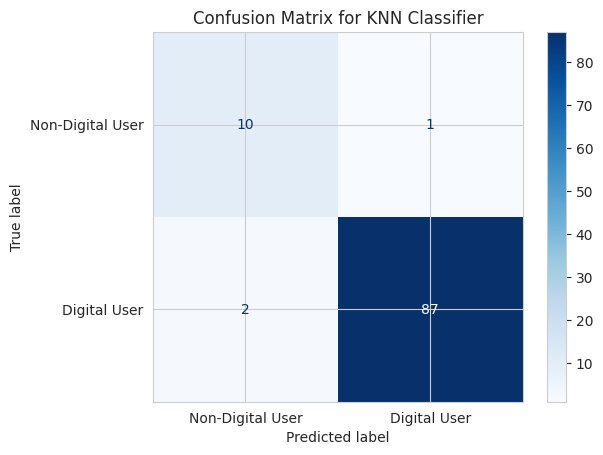


KNN Model built and evaluated.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# Build and train the KNN Classification Model

# Create the KNN pipeline
knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', KNeighborsClassifier(n_neighbors=5))]) # Starting with n_neighbors=5

# Train the model
knn_pipeline.fit(X_train, y_train)

print("KNN model trained successfully.")

# Make predictions on the test set
y_pred = knn_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nModel Evaluation (n_neighbors=5):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix, index=['Actual Non-Digital', 'Actual Digital'], columns=['Predicted Non-Digital', 'Predicted Digital']))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(conf_matrix, display_labels=['Non-Digital User', 'Digital User']).plot(cmap='Blues')
plt.title('Confusion Matrix for KNN Classifier')
plt.show()

print("\nKNN Model built and evaluated.")


Model Evaluation (n_neighbors=5):
Accuracy: 0.9700
Precision: 0.9886
Recall: 0.9775
F1-Score: 0.9831

Confusion Matrix:


,Predicted Non-Digital,Predicted Digital
Actual Non-Digital,10,1
Actual Digital,2,87


<Figure size 800x600 with 0 Axes>

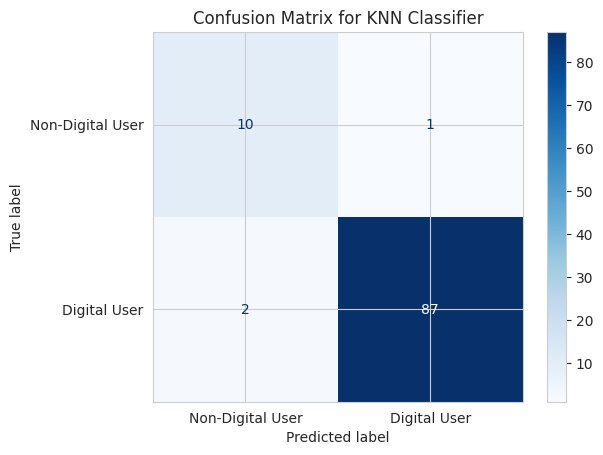


KNN Model built and evaluated.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# Build and train the KNN Classification Model

# Create the KNN pipeline
knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', KNeighborsClassifier(n_neighbors=5))]) # Starting with n_neighbors=5

# Train the model
knn_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nModel Evaluation (n_neighbors=5):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix, index=['Actual Non-Digital', 'Actual Digital'], columns=['Predicted Non-Digital', 'Predicted Digital']))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(conf_matrix, display_labels=['Non-Digital User', 'Digital User']).plot(cmap='Blues')
plt.title('Confusion Matrix for KNN Classifier')
plt.show()

print("\nKNN Model built and evaluated.")

/tmp/ipykernel_751/3775190413.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group_ratios.index, y=age_group_ratios['Digital_Ratio'], palette='viridis')


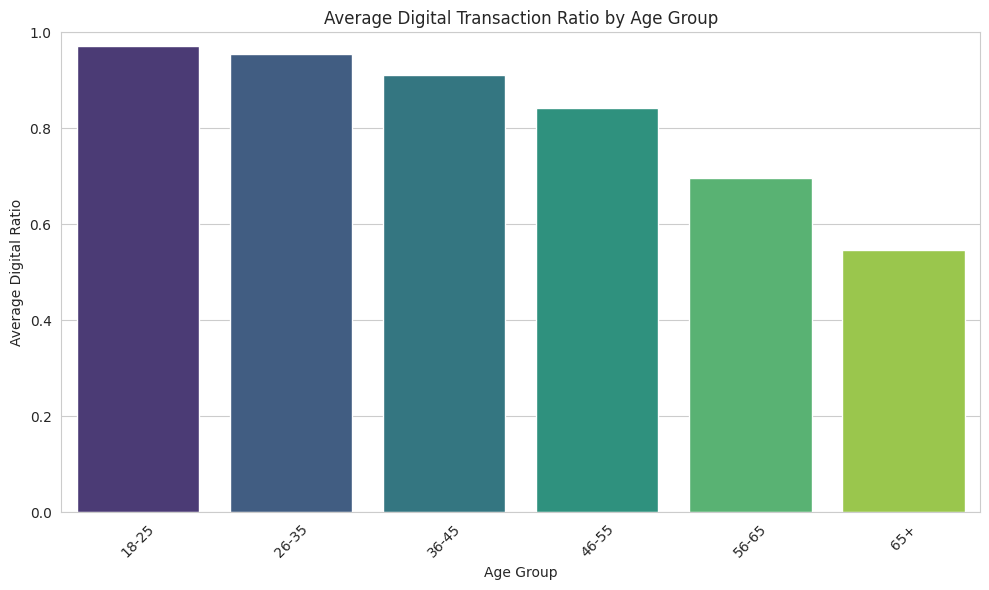

/tmp/ipykernel_751/3775190413.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=occupation_transactions.index, y=occupation_transactions['Total_Transactions'], palette='magma')


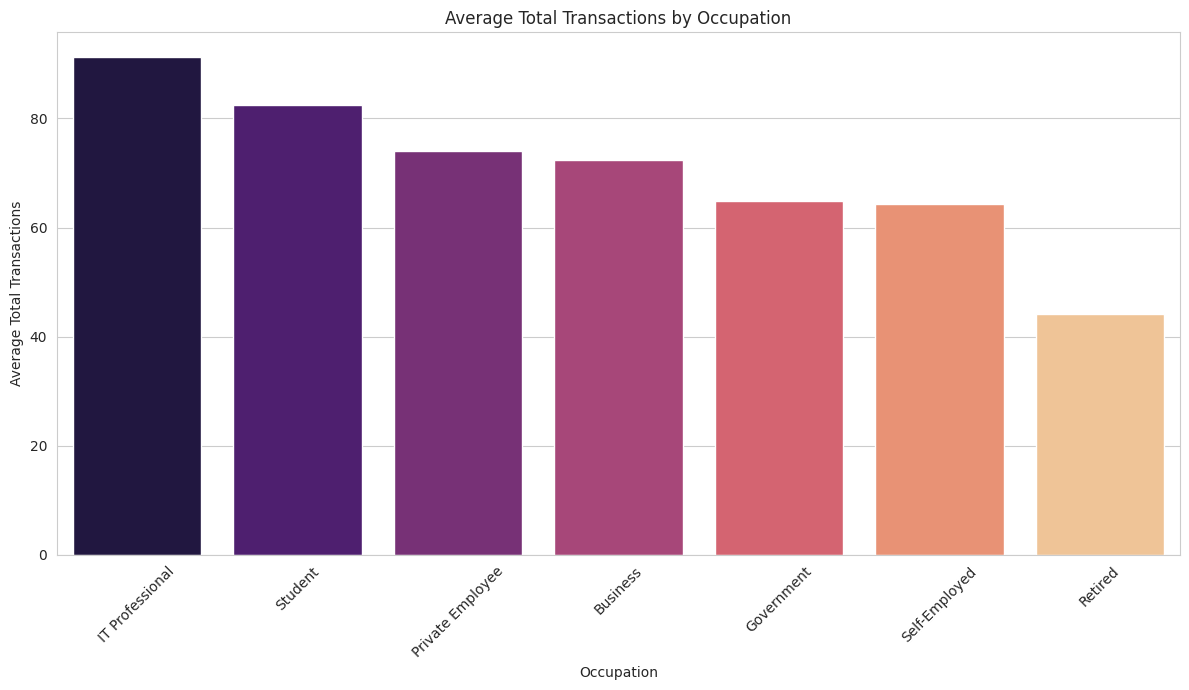

/tmp/ipykernel_751/3775190413.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_transactions.index, y=city_transactions['ATM_Count'], palette='cividis')


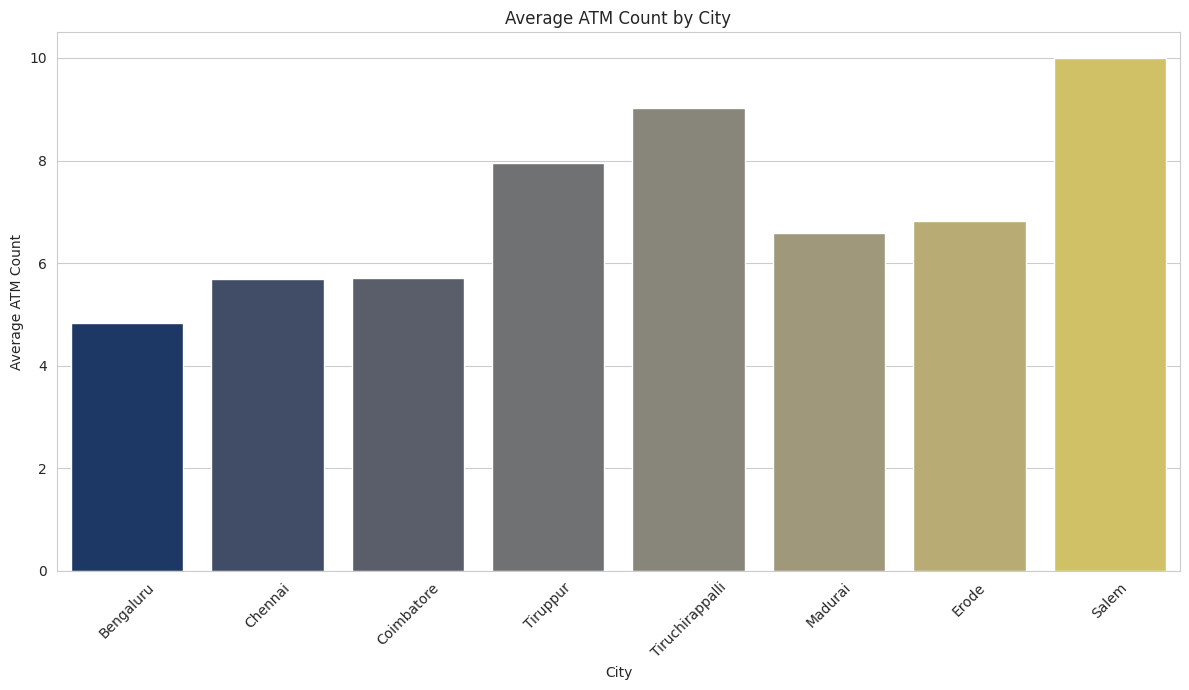

/tmp/ipykernel_751/3775190413.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Digital_User', data=df, palette='plasma')


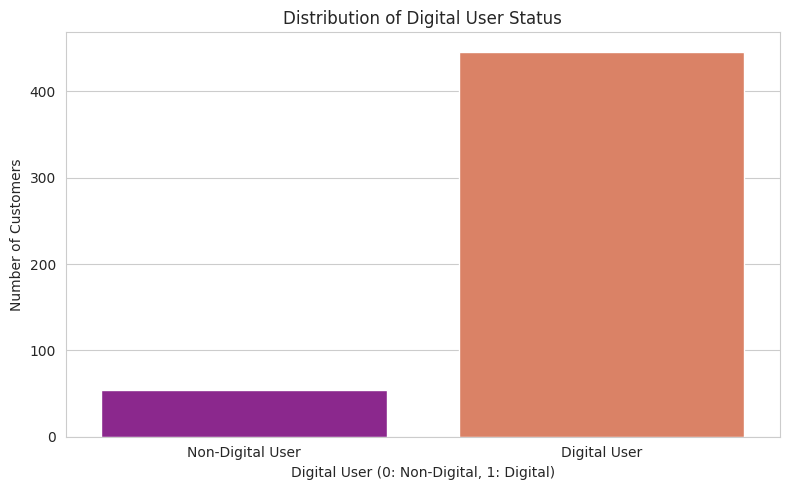

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Visualization 1: Digital_Ratio Distribution by Age_Group
plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_ratios.index, y=age_group_ratios['Digital_Ratio'], palette='viridis')
plt.title('Average Digital Transaction Ratio by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Digital Ratio')
plt.ylim(0, 1) # Ratio is between 0 and 1
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualization 2: Total_Transactions by Occupation
plt.figure(figsize=(12, 7))
sns.barplot(x=occupation_transactions.index, y=occupation_transactions['Total_Transactions'], palette='magma')
plt.title('Average Total Transactions by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Average Total Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualization 3: ATM_Count Distribution by City
plt.figure(figsize=(12, 7))
sns.barplot(x=city_transactions.index, y=city_transactions['ATM_Count'], palette='cividis')
plt.title('Average ATM Count by City')
plt.xlabel('City')
plt.ylabel('Average ATM Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualization 4: Distribution of Digital_User (Target Variable)
plt.figure(figsize=(8, 5))
sns.countplot(x='Digital_User', data=df, palette='plasma')
plt.title('Distribution of Digital User Status')
plt.xlabel('Digital User (0: Non-Digital, 1: Digital)')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['Non-Digital User', 'Digital User'])
plt.tight_layout()
plt.show()

In [ ]:
# Display the truncated outputs for Total Transaction Volume by Occupation and City
print("\nTotal Transaction Volume by Occupation (complete view):")
display(occupation_transactions['Total_Transactions'])

print("\nTotal Transaction Volume by City (complete view):")
display(city_transactions['Total_Transactions'])


Total Transaction Volume by Occupation (complete view):


,Total_Transactions
Occupation,
IT Professional,91.237624
Student,82.524752
Private Employee,74.038961
Business,72.434783
Government,64.949153
Self-Employed,64.394366
Retired,44.090909



Total Transaction Volume by City (complete view):


,Total_Transactions
City,
Bengaluru,94.652778
Chennai,83.130000
Coimbatore,73.481013
Tiruppur,71.448980
Tiruchirappalli,69.955556
Madurai,65.250000
Erode,64.821429
Salem,64.212766


In [ ]:
# Outlier Analysis: Identify unusually high transaction patterns
print("\nIdentifying unusually high transaction patterns (Outliers):")

# Define transaction-related columns to check for outliers
transaction_cols = ['UPI_Count', 'Card_Count', 'ATM_Count', 'Bill_Payments', 'Deposits', 'Withdrawals', 'Digital_Transactions', 'Total_Transactions']

# Using IQR method to identify outliers
outlier_summary = {}
for col in transaction_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if not outliers.empty:
        outlier_summary[col] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(df)) * 100,
            'max_value': outliers[col].max(),
            'min_value': outliers[col].min(),
            'median_value': outliers[col].median()
        }

if outlier_summary:
    print("Outliers detected in the following columns (using IQR method):")
    for col, stats in outlier_summary.items():
        print(f"- {col}: {stats['count']} outliers ({stats['percentage']:.2f}% of data). Max: {stats['max_value']}, Min: {stats['min_value']}, Median: {stats['median_value']}")
        # Optionally display some of the outlier rows
        # display(df[df[col] > upper_bound].head())
else:
    print("No significant outliers detected using the IQR method.")


Identifying unusually high transaction patterns (Outliers):
Outliers detected in the following columns (using IQR method):
- UPI_Count: 9 outliers (1.80% of data). Max: 225, Min: 81, Median: 111.0
- Card_Count: 11 outliers (2.20% of data). Max: 69, Min: 44, Median: 48.0
- ATM_Count: 26 outliers (5.20% of data). Max: 72, Min: 20, Median: 24.0
- Bill_Payments: 12 outliers (2.40% of data). Max: 36, Min: 23, Median: 24.0
- Deposits: 21 outliers (4.20% of data). Max: 296378, Min: 136542, Median: 159776.0
- Withdrawals: 30 outliers (6.00% of data). Max: 114715, Min: 37072, Median: 44110.5
- Digital_Transactions: 8 outliers (1.60% of data). Max: 330, Min: 145, Median: 200.5
- Total_Transactions: 19 outliers (3.80% of data). Max: 348, Min: 134, Median: 154.0


In [ ]:
# Display the truncated outputs for Total Transaction Volume by Occupation and City
print("\nTotal Transaction Volume by Occupation (complete view):")
display(occupation_transactions['Total_Transactions'])

print("\nTotal Transaction Volume by City (complete view):")
display(city_transactions['Total_Transactions'])


Total Transaction Volume by Occupation (complete view):


,Total_Transactions
Occupation,
IT Professional,91.237624
Student,82.524752
Private Employee,74.038961
Business,72.434783
Government,64.949153
Self-Employed,64.394366
Retired,44.090909



Total Transaction Volume by City (complete view):


,Total_Transactions
City,
Bengaluru,94.652778
Chennai,83.130000
Coimbatore,73.481013
Tiruppur,71.448980
Tiruchirappalli,69.955556
Madurai,65.250000
Erode,64.821429
Salem,64.212766


In [ ]:
# Outlier Analysis: Identify unusually high transaction patterns
print("\nIdentifying unusually high transaction patterns (Outliers):")

# Define transaction-related columns to check for outliers
transaction_cols = ['UPI_Count', 'Card_Count', 'ATM_Count', 'Bill_Payments', 'Deposits', 'Withdrawals', 'Digital_Transactions', 'Total_Transactions']

# Using IQR method to identify outliers
outlier_summary = {}
for col in transaction_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if not outliers.empty:
        outlier_summary[col] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(df)) * 100,
            'max_value': outliers[col].max(),
            'min_value': outliers[col].min(),
            'median_value': outliers[col].median()
        }

if outlier_summary:
    print("Outliers detected in the following columns (using IQR method):")
    for col, stats in outlier_summary.items():
        print(f"- {col}: {stats['count']} outliers ({stats['percentage']:.2f}% of data). Max: {stats['max_value']}, Min: {stats['min_value']}, Median: {stats['median_value']}")
        # Optionally display some of the outlier rows
        # display(df[df[col] > upper_bound].head())
else:
    print("No significant outliers detected using the IQR method.")


Identifying unusually high transaction patterns (Outliers):
Outliers detected in the following columns (using IQR method):
- UPI_Count: 9 outliers (1.80% of data). Max: 225, Min: 81, Median: 111.0
- Card_Count: 11 outliers (2.20% of data). Max: 69, Min: 44, Median: 48.0
- ATM_Count: 26 outliers (5.20% of data). Max: 72, Min: 20, Median: 24.0
- Bill_Payments: 12 outliers (2.40% of data). Max: 36, Min: 23, Median: 24.0
- Deposits: 21 outliers (4.20% of data). Max: 296378, Min: 136542, Median: 159776.0
- Withdrawals: 30 outliers (6.00% of data). Max: 114715, Min: 37072, Median: 44110.5
- Digital_Transactions: 8 outliers (1.60% of data). Max: 330, Min: 145, Median: 200.5
- Total_Transactions: 19 outliers (3.80% of data). Max: 348, Min: 134, Median: 154.0


In [ ]:
# Display the truncated output for ATM Ratio by City
print("\nAverage ATM Ratio by City (complete view):")
display(city_ratios['ATM_Ratio'])


Average ATM Ratio by City (complete view):


,ATM_Ratio
City,
Bengaluru,0.063498
Chennai,0.089193
Coimbatore,0.097003
Erode,0.122179
Madurai,0.122431
Tiruppur,0.140007
Tiruchirappalli,0.149841
Salem,0.171726


In [ ]:
# EDA: Analysis of Total transaction volume
print("\nDescriptive statistics for Total Transactions:")
display(df['Total_Transactions'].describe())

print("\nTotal Transaction Volume by Age Group:")
display(age_group_transactions['Total_Transactions'])

print("\nTotal Transaction Volume by Occupation:")
display(occupation_transactions['Total_Transactions'])

print("\nTotal Transaction Volume by City:")
display(city_transactions['Total_Transactions'])


Descriptive statistics for Total Transactions:


,Total_Transactions
count,500.000000
mean,75.246000
std,30.971082
min,27.000000
25%,56.000000
50%,69.000000
75%,87.000000
max,348.000000



Total Transaction Volume by Age Group:


,Total_Transactions
Age_Group,
18-25,90.534483
26-35,82.304000
36-45,74.474138
46-55,62.142857
56-65,55.816327
65+,46.208333



Total Transaction Volume by Occupation:


,Total_Transactions
Occupation,
IT Professional,91.237624
Student,82.524752
Private Employee,74.038961
Business,72.434783
Government,64.949153
Self-Employed,64.394366
Retired,44.090909



Total Transaction Volume by City:


,Total_Transactions
City,
Bengaluru,94.652778
Chennai,83.130000
Coimbatore,73.481013
Tiruppur,71.448980
Tiruchirappalli,69.955556
Madurai,65.250000
Erode,64.821429
Salem,64.212766
